## ***Importing all Libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pp = pd.read_csv('patient_priority.csv', index_col = 0)
pp.head()

,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status,triage
0,40.0,1.0,2.0,140.0,294.0,172.0,0.0,108.0,43.0,92.0,19.0,0.467386,0.0,0.0,Urban,never smoked,yellow
1,49.0,0.0,3.0,160.0,180.0,156.0,0.0,75.0,47.0,90.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
2,37.0,1.0,2.0,130.0,294.0,156.0,0.0,98.0,53.0,102.0,23.0,0.467386,0.0,0.0,Urban,never smoked,yellow
3,48.0,0.0,4.0,138.0,214.0,156.0,1.0,72.0,51.0,118.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
4,54.0,1.0,3.0,150.0,195.0,156.0,0.0,108.0,90.0,83.0,21.0,0.467386,0.0,0.0,Urban,never smoked,yellow


### ***Information of data***

In [3]:
pp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6962 entries, 0 to 5109
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                6962 non-null   float64
 1   gender             6961 non-null   float64
 2   chest pain type    6962 non-null   float64
 3   blood pressure     6962 non-null   float64
 4   cholesterol        6962 non-null   float64
 5   max heart rate     6962 non-null   float64
 6   exercise angina    6962 non-null   float64
 7   plasma glucose     6962 non-null   float64
 8   skin_thickness     6962 non-null   float64
 9   insulin            6962 non-null   float64
 10  bmi                6962 non-null   float64
 11  diabetes_pedigree  6962 non-null   float64
 12  hypertension       6962 non-null   float64
 13  heart_disease      6962 non-null   float64
 14  Residence_type     6962 non-null   object 
 15  smoking_status     6962 non-null   object 
 16  triage             6552 non-n

### ***Null value Detection***

In [4]:
pp.isna().sum()

age                    0
gender                 1
chest pain type        0
blood pressure         0
cholesterol            0
max heart rate         0
exercise angina        0
plasma glucose         0
skin_thickness         0
insulin                0
bmi                    0
diabetes_pedigree      0
hypertension           0
heart_disease          0
Residence_type         0
smoking_status         0
triage               410
dtype: int64

### ***Outlier detection***

In [5]:
num = pp.select_dtypes(include = 'float').drop('gender', axis = 1)
num.columns

Index(['age', 'chest pain type', 'blood pressure', 'cholesterol',
       'max heart rate', 'exercise angina', 'plasma glucose', 'skin_thickness',
       'insulin', 'bmi', 'diabetes_pedigree', 'hypertension', 'heart_disease'],
      dtype='object')

In [6]:
def outliers(x):
    j = 1
    plt.figure(figsize = (15, 7))
    for i in x.columns:
        plt.subplot(4, 4, j)
        sns.boxplot(y = x[i], color= 'maroon')
        j +=1
    plt.show()


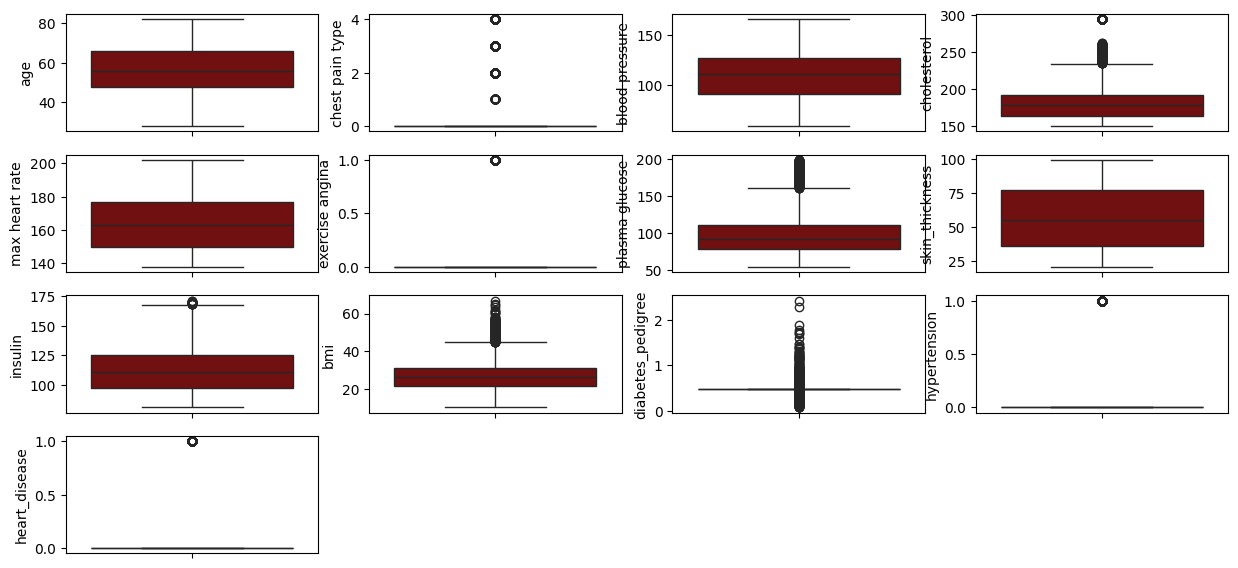

In [7]:
outliers(num)

### ***Correlation between all the attributes***

In [8]:
num2 = pp.select_dtypes(include = ['int', 'float'])

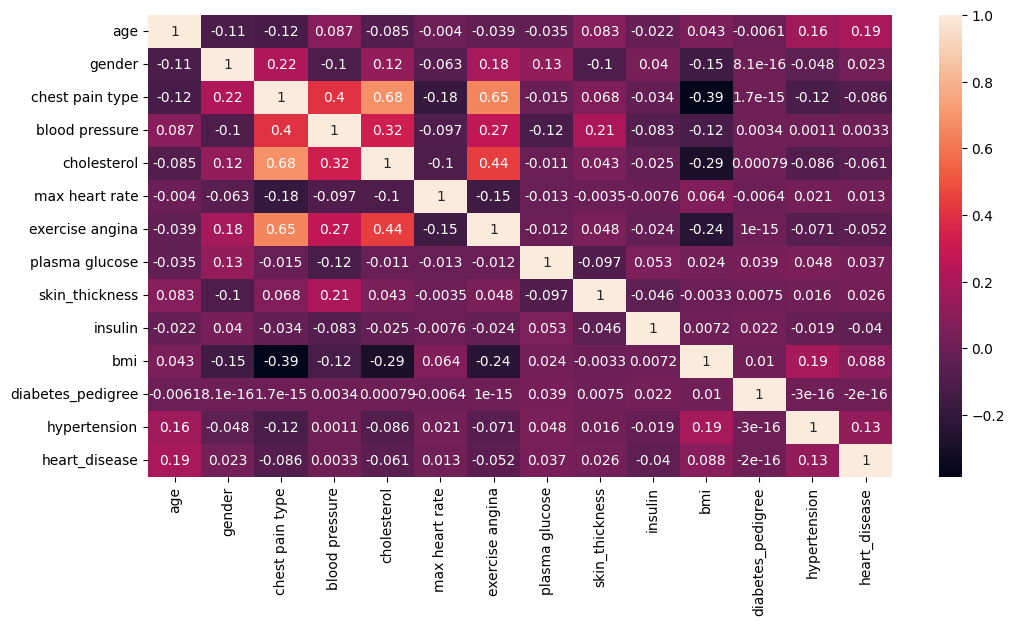

In [9]:
plt.figure(figsize = (12, 6))
sns.heatmap(num2.corr(), annot = True)
plt.show()

### ***Correlation between categorical - categorical columns***

In [10]:
obj = pp.select_dtypes(include = 'object')
obj.columns

Index(['Residence_type', 'smoking_status', 'triage'], dtype='object')

In [11]:
from scipy.stats import chi2_contingency
smoking_status_in_residence = pd.crosstab(pp['Residence_type'], pp['smoking_status'])
smoking_status_in_residence

smoking_status,Unknown,formerly smoked,never smoked,smokes
Residence_type,,,,
Rural,762,428,960,363
Urban,782,456,2785,426


In [12]:
def chi_squared_test(x, alpha):
    chi2_stat, p_val, dof, expected_freq = chi2_contingency(x)
    print(f'chi2_stat : {chi2_stat} \nP - Value : {p_val} \nDegree of freedom : {dof} \nExpected Frequency : {expected_freq}')
    if p_val < alpha:
        return 'There is an association between the two columns'
    else:
        return 'There is no association between the two columns'

In [13]:
a = chi_squared_test(smoking_status_in_residence, 0.05)
a

chi2_stat : 387.0979087816239 
P - Value : 1.3795111426375457e-83 
Degree of freedom : 3 
Expected Frequency : [[ 557.32145935  319.08819305 1351.79330652  284.79704108]
 [ 986.67854065  564.91180695 2393.20669348  504.20295892]]


'There is an association between the two columns'

In [14]:
smoking_triage = pd.crosstab(pp['triage'], pp['smoking_status'])
smoking_triage

smoking_status,Unknown,formerly smoked,never smoked,smokes
triage,,,,
green,70,67,254,49
orange,76,17,253,0
red,0,0,129,0
yellow,1240,770,2907,720


In [15]:
b = chi_squared_test(smoking_triage, 0.05)
b

chi2_stat : 214.84258165674743 
P - Value : 2.5406568460598353e-41 
Degree of freedom : 9 
Expected Frequency : [[  93.07692308   57.35042735  237.93040293   51.64224664]
 [  73.19230769   45.0982906   187.09981685   40.60958486]
 [  27.28846154   16.81410256   69.75686813   15.14056777]
 [1192.44230769  734.73717949 3048.21291209  661.60760073]]


'There is an association between the two columns'

In [16]:
triage_of_residence_type = pd.crosstab(pp['Residence_type'], pp['triage'])
triage_of_residence_type

triage,green,orange,red,yellow
Residence_type,,,,
Rural,154,79,0,2132
Urban,286,267,129,3505


In [17]:
c = chi_squared_test(triage_of_residence_type, 0.05)
c

chi2_stat : 106.75934392039957 
P - Value : 5.465857887771341e-23 
Degree of freedom : 3 
Expected Frequency : [[ 158.82173382  124.89163614   46.56364469 2034.72298535]
 [ 281.17826618  221.10836386   82.43635531 3602.27701465]]


'There is an association between the two columns'

- #### ***The chi Squared test only tells whether there is an association between the two columns or not.***
- #### ***To find the strength, we use Cramer's V Rule***

In [18]:
def cramers_v_rule(col, chi2_stat):
    n = col.values.sum()
    c = col.shape[1]
    r = col.shape[0]
    min_dim = min(r-1, c-1)
    strength = np.sqrt(chi2_stat / (n*min_dim))
    return strength

In [19]:
cramers_v_rule(smoking_status_in_residence, 387.0979087816239)

np.float64(0.2357997840882065)

In [20]:
cramers_v_rule(smoking_triage, 214.84258165674743)

np.float64(0.10454724899256937)

In [21]:
cramers_v_rule(triage_of_residence_type, 106.75934392039957)

np.float64(0.127648584637716)

### ***Splitting the data in train and test***

In [22]:
from sklearn.model_selection import train_test_split
x_train, x_test = train_test_split(pp, test_size=0.25, random_state = 42)

In [23]:
x_train.shape

(5221, 17)

In [24]:
x_test.shape

(1741, 17)

## ***Data preprocessing***

### ***Encoding***

In [25]:
pp.select_dtypes(include = 'object').columns

Index(['Residence_type', 'smoking_status', 'triage'], dtype='object')

In [26]:
pp['Residence_type'].value_counts()

Residence_type
Urban    4449
Rural    2513
Name: count, dtype: int64

In [27]:
x_train['Residence_type'] = x_train['Residence_type'].apply(lambda x : 1 if x == 'Urban' else 0)
x_train['Residence_type'].value_counts()

Residence_type
1    3289
0    1932
Name: count, dtype: int64

In [28]:
x_test['Residence_type'] = x_test['Residence_type'].apply(lambda x : 1 if x == 'Urban' else 0)
x_test['Residence_type'].value_counts()

Residence_type
1    1160
0     581
Name: count, dtype: int64

In [29]:
pp['smoking_status'].value_counts()

smoking_status
never smoked       3745
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64

In [30]:
def smoke(x):
    if x == 'never smoked':
        return 0
    elif x == 'Unknown':
        return 1
    elif x == 'formerly smoked':
        return 2
    else:
        return 3

In [31]:
x_train['smoking_status'] = x_train['smoking_status'].apply(smoke)
x_train['smoking_status'].value_counts()

smoking_status
0    2766
1    1171
2     681
3     603
Name: count, dtype: int64

In [32]:
x_test['smoking_status'] = x_test['smoking_status'].apply(smoke)
x_test['smoking_status'].value_counts()

smoking_status
0    979
1    373
2    203
3    186
Name: count, dtype: int64

In [33]:
pp['triage'].value_counts()

triage
yellow    5637
green      440
orange     346
red        129
Name: count, dtype: int64

### ***PD.FACTORIZE encodes categorical columns and assign -1 to the nan values***

In [34]:
code, unique = pd.factorize(x_train['triage'])
np.unique(code)

array([-1,  0,  1,  2,  3])

In [35]:
code2, unique2 = pd.factorize(x_test['triage'])
np.unique(code2)

array([-1,  0,  1,  2,  3])

In [36]:
x_train['triage'] = code
x_train['triage'].value_counts()

triage
 0    4227
 1     329
-1     308
 3     264
 2      93
Name: count, dtype: int64

In [37]:
x_test['triage'] = code2
x_test['triage'].value_counts()

triage
 0    1410
 2     111
-1     102
 1      82
 3      36
Name: count, dtype: int64

In [38]:
x_train['triage'].replace(-1, np.nan, inplace = True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8112\2794484212.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train['triage'].replace(-1, np.nan, inplace = True)


In [39]:
x_test['triage'].replace(-1, np.nan, inplace = True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8112\3054404299.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_test['triage'].replace(-1, np.nan, inplace = True)


### ***Imputation***

In [40]:
x_train.isna().sum()

age                    0
gender                 1
chest pain type        0
blood pressure         0
cholesterol            0
max heart rate         0
exercise angina        0
plasma glucose         0
skin_thickness         0
insulin                0
bmi                    0
diabetes_pedigree      0
hypertension           0
heart_disease          0
Residence_type         0
smoking_status         0
triage               308
dtype: int64

In [41]:
x_test.isna().sum()

age                    0
gender                 0
chest pain type        0
blood pressure         0
cholesterol            0
max heart rate         0
exercise angina        0
plasma glucose         0
skin_thickness         0
insulin                0
bmi                    0
diabetes_pedigree      0
hypertension           0
heart_disease          0
Residence_type         0
smoking_status         0
triage               102
dtype: int64

In [42]:
from sklearn.impute import KNNImputer
imputer = KNNImputer()
x_train['gender'] = imputer.fit_transform(x_train[['gender']])
x_train['triage'] = imputer.fit_transform(x_train[['triage']])
x_train['gender'].isna().sum(), x_train['triage'].isna().sum()

(np.int64(0), np.int64(0))

In [43]:
x_test['triage'] = imputer.transform(x_test[['triage']])
x_test['gender'].isna().sum(), x_test['triage'].isna().sum()

(np.int64(0), np.int64(0))

### ***Outlier treatment***

In [44]:
outlier_cols = ['chest pain type', 'heart_disease', 'hypertension', 'diabetes_pedigree', 'bmi', 'insulin', 'plasma glucose', 'exercise angina', 'cholesterol']
outlier_cols

['chest pain type',
 'heart_disease',
 'hypertension',
 'diabetes_pedigree',
 'bmi',
 'insulin',
 'plasma glucose',
 'exercise angina',
 'cholesterol']

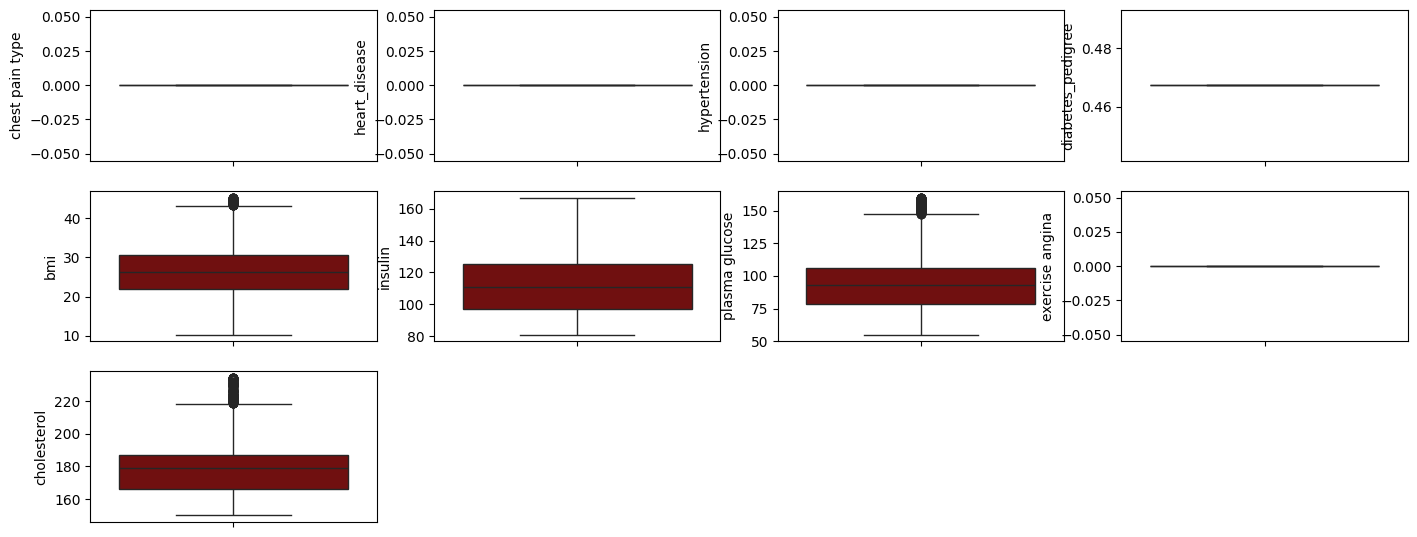

In [45]:
for i in outlier_cols:
    q1 = x_train[i].quantile(0.25)
    q3 = x_train[i].quantile(0.75)
    iqr = q3 - q1

    upper = q3 + 1.5*iqr
    lower = q1 - 1.5*iqr

    idx = x_train[(x_train[i] > upper) | (x_train[i] < lower)].index

    median = x_train[i].median()

    x_train.loc[idx, i] = median

j = 1
plt.figure(figsize = (17, 9))
for i in outlier_cols:
    plt.subplot(4, 4, j)
    sns.boxplot(y = x_train[i], color= 'maroon')
    j +=1
plt.show()    

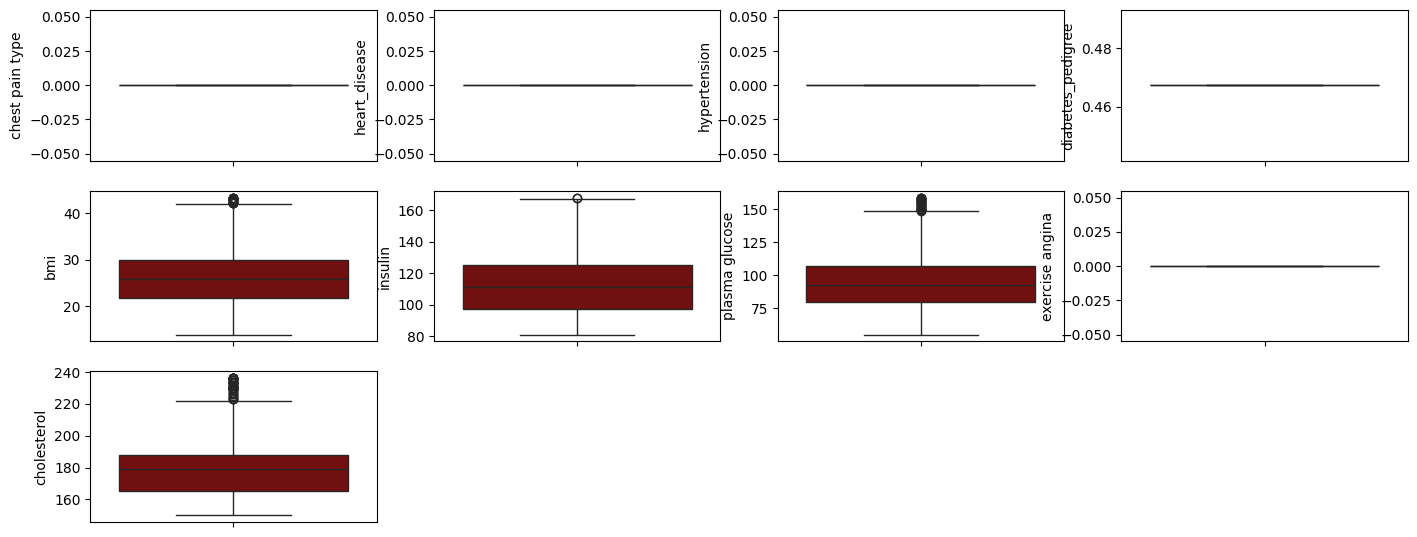

In [46]:
for i in outlier_cols:
    q1 = x_test[i].quantile(0.25)
    q3 = x_test[i].quantile(0.75)
    iqr = q3 - q1

    upper = q3 + 1.5*iqr
    lower = q1 - 1.5*iqr

    idx = x_test[(x_test[i] > upper) | (x_test[i] < lower)].index

    median = x_train[i].median()

    x_test.loc[idx, i] = median

j = 1
plt.figure(figsize = (17, 9))
for i in outlier_cols:
    plt.subplot(4, 4, j)
    sns.boxplot(y = x_test[i], color= 'maroon')
    j +=1
plt.show()    

### ***Standardization***

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train[x_train.columns] = scaler.fit_transform(x_train)
x_train.head()

,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status,triage
573,0.550879,0.942004,0.0,1.867209,0.998284,-0.223441,0.0,1.305013,0.180775,-1.103527,-1.052590,5.551115e-17,0.0,0.0,0.766428,-0.795163,-0.367943
3533,1.137487,0.942004,0.0,-0.315994,1.062573,-1.256787,0.0,0.060572,-0.080975,1.576599,-0.818214,5.551115e-17,0.0,0.0,-1.304753,-0.795163,-0.367943
454,-1.292747,-1.061770,0.0,1.077540,0.291105,-0.869282,0.0,0.877774,0.747901,0.993963,1.791173,5.551115e-17,0.0,0.0,-1.304753,-0.795163,-0.367943
3218,-1.376548,0.942004,0.0,1.170442,-1.573277,-0.610945,0.0,0.953760,1.794902,-0.462627,-0.068210,5.551115e-17,0.0,0.0,-1.304753,-0.795163,-0.367943
4619,-0.035729,-1.061770,0.0,-0.130190,-0.801809,-0.158856,0.0,-0.845519,-0.909851,0.178273,1.744298,5.551115e-17,0.0,0.0,0.766428,0.160974,-0.367943


In [48]:
x_test[x_test.columns] = scaler.fit_transform(x_test)
x_test.head()

,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status,triage
213,0.209791,0.926314,0.0,-2.047824,0.773601,-1.081434,0.0,2.173338,-1.346902,1.096448,0.231414,2.220446e-16,0.0,0.0,0.707716,-0.748582,-0.385209
3826,1.479184,-1.079548,0.0,0.087647,-1.399384,1.129466,0.0,0.016141,-0.249549,0.114763,0.149238,2.220446e-16,0.0,0.0,-1.412996,-0.748582,-0.385209
4154,-0.721097,-1.079548,0.0,0.598303,0.186308,-0.951381,0.0,1.487976,-0.820173,-1.328893,0.001322,2.220446e-16,0.0,0.0,-1.412996,0.226198,-0.385209
37,-1.398106,-1.079548,0.0,0.041224,0.068849,-1.406566,0.0,0.122499,0.540546,1.385179,-0.869742,2.220446e-16,0.0,0.0,0.707716,-0.748582,-0.385209
3784,0.463670,-1.079548,0.0,1.341076,1.067248,0.674281,0.0,-0.392119,0.145499,-1.675370,2.105022,2.220446e-16,0.0,0.0,-1.412996,-0.748582,-0.385209


## ***Clustering***

### ***K-means cluster***

In [49]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 4, init = 'random', random_state = 42)
kmeans.fit(x_train) 

,n_clusters,4
,init,'random'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [50]:
kmeans.inertia_

47624.8220291439

In [51]:
labels = kmeans.predict(x_train)
labels

array([3, 3, 2, ..., 0, 2, 3], shape=(5221,), dtype=int32)

In [52]:
labels2 = kmeans.predict(x_test)
labels2

array([0, 2, 2, ..., 0, 2, 3], shape=(1741,), dtype=int32)

In [53]:
from sklearn.metrics import silhouette_score
silhouette_score(x_train, kmeans.labels_)

0.10843464395035636

In [54]:
silhouette_score(x_test, labels2)

0.09752544083729266

### ***Checking the performance using hyperparameter tuning***

In [55]:
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init = 'random', random_state= 42)
    result = kmeans.fit(x_train)
    inertias.append(result.inertia_)
inertias

[62651.99999999995,
 55669.099607034615,
 51125.89247823526,
 47624.8220291439,
 44539.595642867454,
 42745.79754984399,
 41209.54024653867,
 40177.4298201626,
 39140.6850906639,
 38364.14966681365]

In [94]:
silhot_score = []
for k in range(2, 10):
    kmeans2 = KMeans(n_clusters=k, init = 'random', random_state=42)
    result2 = kmeans2.fit(x_train)
    score = silhouette_score(x_train, result2.labels_)
    print(score)

0.11014554316052058
0.11620354007076274
0.10843464395035636
0.1183897012284145
0.1244522824725185
0.12536194640190404
0.12495140795895898
0.12431002912273155


### ***2D visualization using t-sne***

In [57]:
from sklearn.manifold import TSNE
t_sne = TSNE(2)
data = t_sne.fit_transform(x_train)

clusters = pd.DataFrame(data, columns = ['x1', 'x2'])
clusters['labels'] = labels
clusters.head()

,x1,x2,labels
0,-30.195354,13.395791,3
1,31.399345,-59.575024,3
2,37.440876,18.968895,2
3,28.877007,-42.577343,2
4,21.466085,43.454426,2


In [58]:
def viz_clusters(df):
    plt.figure(figsize = (6, 4))
    sns.scatterplot(x = 'x1', y = 'x2', data = df, hue = 'labels', s = 60, palette = 'tab10', alpha = 0.8)
    plt.legend(title = 'Cluster')
    plt.title('T-sne cluster visualization')
    plt.show()

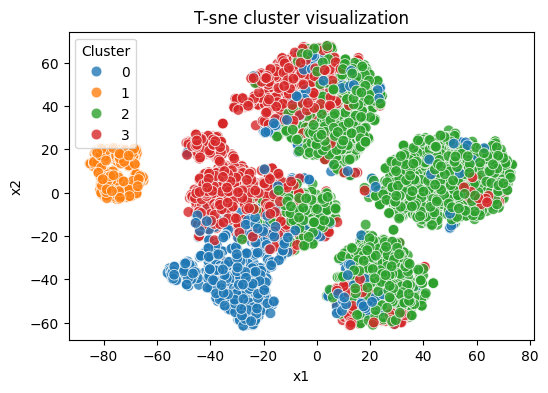

In [59]:
viz_clusters(clusters)

## ***Guassian Mixture Model***

In [60]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components = 3)
gmm.fit(x_train)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


In [61]:
gm_labels = gmm.predict(x_train)
np.unique(gm_labels)

array([0, 1, 2])

In [62]:
test_labels = gmm.predict(x_test)
np.unique(test_labels)

array([1])

In [63]:
silhouette_score(x_train, gm_labels)

0.07048398524274459

In [64]:
data2 = t_sne.fit_transform(x_train)
clusters2 = pd.DataFrame(data2, columns = ['x1','x2'])
clusters2['labels'] = gm_labels
clusters2.head()

,x1,x2,labels
0,-30.195354,13.395791,0
1,31.399345,-59.575024,0
2,37.440876,18.968895,0
3,28.877007,-42.577343,0
4,21.466085,43.454426,0


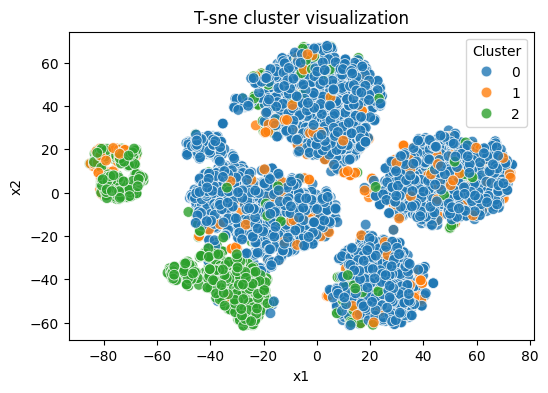

In [65]:
viz_clusters(clusters2)

In [66]:
from scipy.cluster import hierarchy
z = hierarchy.linkage(x_train, method = 'ward')
z.shape

(5220, 4)

In [67]:
z

array([[7.85000000e+02, 1.13500000e+03, 3.04383027e-01, 2.00000000e+00],
       [3.12600000e+03, 4.56600000e+03, 3.05725105e-01, 2.00000000e+00],
       [3.09200000e+03, 4.75700000e+03, 4.23298809e-01, 2.00000000e+00],
       ...,
       [1.04230000e+04, 1.04370000e+04, 8.16242677e+01, 3.11500000e+03],
       [1.04360000e+04, 1.04380000e+04, 1.00645726e+02, 4.89200000e+03],
       [1.04250000e+04, 1.04390000e+04, 1.05285345e+02, 5.22100000e+03]],
      shape=(5220, 4))

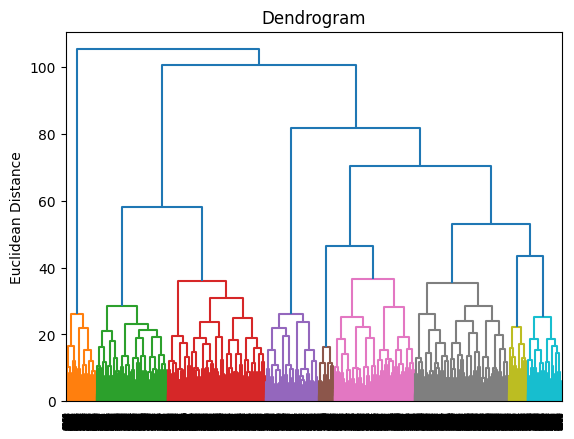

In [68]:
hierarchy.dendrogram(z, color_threshold = 40)
plt.title('Dendrogram')
plt.ylabel('Euclidean Distance')
plt.show()

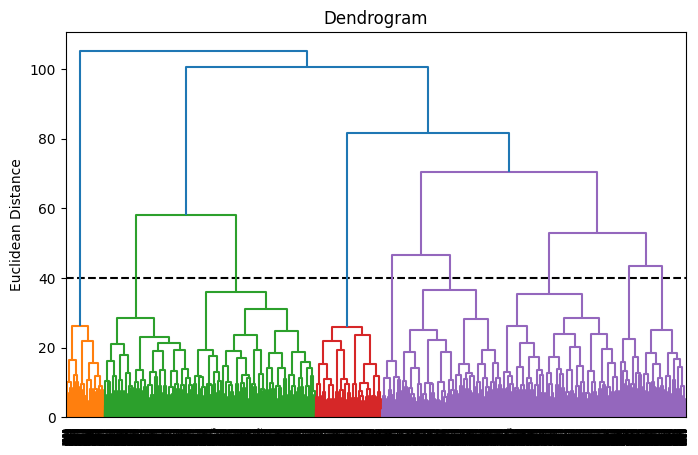

In [71]:
fig, ax = plt.subplots(figsize = (8, 5))
plt.axhline(y = 40, color = 'black', linestyle = '--')
hierarchy.dendrogram(z)
plt.title('Dendrogram')
plt.ylabel('Euclidean Distance')
plt.show()

### ***Performing Agglomerative clustering***

In [ ]:
from sklearn.cluster import AgglomerativeClustering
aglo_cluster = AgglomerativeClustering(n_clusters = 4, linkage = 'ward', metric = 'euclidean')
labels = aglo_cluster.fit_predict(x_train)
labels

array([0, 2, 2, ..., 0, 2, 0], shape=(5221,))

In [74]:
np.unique(labels)

array([0, 1, 2, 3])

In [75]:
print(f'Silhouette score : {silhouette_score(x_train, labels)}')

Silhouette score : 0.09631477929660777


### ***Performing hyperparameter tuning***

In [84]:
for i in range(2, 8):
    aglo_model = AgglomerativeClustering(n_clusters= i, metric= 'euclidean', linkage = 'ward')
    predictions = aglo_model.fit_predict(x_train)
    score = silhouette_score(x_train, predictions)
    print(f'For {i} clusters , Silhouette Score is : {score}')

For 2 clusters , Silhouette Score is : 0.2333382917582311
For 3 clusters , Silhouette Score is : 0.11047623038841754
For 4 clusters , Silhouette Score is : 0.09631477929660777
For 5 clusters , Silhouette Score is : 0.09693962653975717
For 6 clusters , Silhouette Score is : 0.09965808484027475
For 7 clusters , Silhouette Score is : 0.10547855209084665


#### **n_clusters = 2 is giving the best Silhouette score.**
#### ***Therefore we will choose n_clusters = 2***

In [98]:
aglo_cluster2 = AgglomerativeClustering(n_clusters = 2, linkage = 'ward', metric = 'euclidean')
pred = aglo_cluster.fit_predict(x_train)
pred

array([0, 2, 2, ..., 0, 2, 0], shape=(5221,))

In [99]:
print('Silhouette Score : ', silhouette_score(x_train, pred))

Silhouette Score :  0.09631477929660777


### ***T-sne Visualization***

In [100]:
t_sne = TSNE(2)
data3 = t_sne.fit_transform(x_train)

clus = pd.DataFrame(data3, columns = ['x1', 'x2'])
clus['labels'] = pred
clus.head()

,x1,x2,labels
0,-30.195354,13.395791,0
1,31.399345,-59.575024,2
2,37.440876,18.968895,2
3,28.877007,-42.577343,2
4,21.466085,43.454426,0


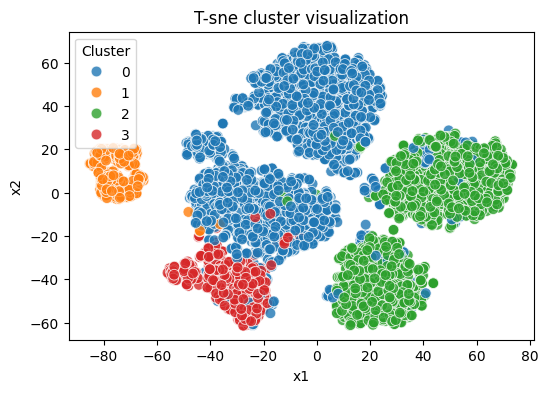

In [101]:
viz_clusters(clus)